# Cell Type Frequency Preprocessing
**AIFI Cell Type Frequencies (L1, L2, L3)**

Sources: `sound_life_AIFI_L[1/2/3]_frequencies.csv`  
Output: `data/processed/celltype_freq_baseline_wide.csv` (all three levels joined)  
Manifest: `data/processed/feature_manifest.csv`

All three resolution levels are retained (L1=9, L2=29, L3=71 types; 109 total features). Subsetting to a specific level for BN fitting can happen at join time or before `hc()`.
Value column: `AIFI_Lx_clr_pseudo` (pseudocount-adjusted CLR; preferred over plain CLR which produces NA for undetected types).

In [1]:
import sys
from functools import reduce
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))

from src.io import append_manifest, enforce_export_contract, write_processed
from src.load import load_csv
from src.qc import assert_no_duplicates, flag_missingness
from src.transforms import to_snake_case

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
FIGURES = Path("../figures/preprocessing")
FIGURES.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

BASELINE_VISIT = "Flu Year 1 Day 0"

# (level, expected n_types per sample at baseline)
LEVELS = [("L1", 9), ("L2", 29), ("L3", 71)]

## Stage 1 - Ingestion & Standardization

In [2]:
raw_dfs = {}
for level, n_types in LEVELS:
    df = load_csv(RAW / ("sound_life_AIFI_" + level + "_frequencies.csv"))
    raw_dfs[level] = df
    print(level + ": shape=" + str(df.shape)
          + "  subjects=" + str(df["subject.subjectGuid"].nunique())
          + "  samples=" + str(df["sample.sampleKitGuid"].nunique())
          + "  cell_types=" + str(df["AIFI_" + level].nunique())
          + "  (expected " + str(n_types) + ")")

L1: shape=(7812, 25)  subjects=96  samples=868  cell_types=9  (expected 9)
L2: shape=(25172, 25)  subjects=96  samples=868  cell_types=29  (expected 29)
L3: shape=(61628, 25)  subjects=96  samples=868  cell_types=71  (expected 71)


## Stages 2-3 - Baseline Filtering & QC

Filter to `sample.visitName == "Flu Year 1 Day 0"` (no `daysSinceFirstVisit` in these files).  
Assert each baseline sample has exactly the expected number of cell type rows.  
Assert no duplicate (sample x cell type) pairs.

In [3]:
baseline_dfs = {}
for level, n_types in LEVELS:
    df = raw_dfs[level]
    baseline = df[df["sample.visitName"] == BASELINE_VISIT].copy()

    # Assert correct number of cell type rows per sample
    type_counts = baseline.groupby("sample.sampleKitGuid")["AIFI_" + level].count()
    bad = type_counts[type_counts != n_types]
    assert bad.empty, level + ": samples without " + str(n_types) + " types:\n" + str(bad)

    # Assert no duplicates
    assert_no_duplicates(baseline, key_cols=["sample.sampleKitGuid", "AIFI_" + level])

    val_miss = baseline["AIFI_" + level + "_clr_pseudo"].isnull().mean()
    baseline_dfs[level] = baseline
    print(level + ": " + str(baseline["sample.sampleKitGuid"].nunique())
          + " baseline samples, " + str(n_types) + " types each."
          + "  clr_pseudo missing=" + str(round(val_miss, 4)) + "  no duplicates.")

L1: 92 baseline samples, 9 types each.  clr_pseudo missing=0.0  no duplicates.
L2: 92 baseline samples, 29 types each.  clr_pseudo missing=0.0  no duplicates.
L3: 92 baseline samples, 71 types each.  clr_pseudo missing=0.0  no duplicates.


## Stage 4 - Pivot Long to Wide & Join Levels

In [4]:
wide_dfs = {}
for level, _ in LEVELS:
    baseline = baseline_dfs[level]
    val_col = "AIFI_" + level + "_clr_pseudo"

    wide = baseline.pivot_table(
        index="sample.sampleKitGuid",
        columns="AIFI_" + level,
        values=val_col,
        aggfunc="first",
    )
    wide.columns = ["freq." + level + "_" + to_snake_case(c) for c in wide.columns]
    wide = wide.reset_index()

    guid_map = (
        baseline[["sample.sampleKitGuid", "subject.subjectGuid"]]
        .drop_duplicates()
        .set_index("sample.sampleKitGuid")
    )
    wide = wide.join(guid_map, on="sample.sampleKitGuid")
    wide_dfs[level] = wide
    print(level + " wide: " + str(wide.shape))

# Outer-join all three levels on ID columns
id_cols = ["subject.subjectGuid", "sample.sampleKitGuid"]
wide_all = reduce(
    lambda l, r: l.merge(r, on=id_cols, how="outer"),
    wide_dfs.values()
)
feat_cols = sorted([c for c in wide_all.columns if c not in id_cols])
wide_all = wide_all[id_cols + feat_cols]

print("\nJoined shape: " + str(wide_all.shape)
      + "  (" + str(wide_all.shape[0]) + " samples x " + str(len(feat_cols)) + " features)")
wide_all.head()

L1 wide: (92, 11)
L2 wide: (92, 31)
L3 wide: (92, 73)

Joined shape: (92, 123)  (92 samples x 109 features)


,subject.subjectGuid,sample.sampleKitGuid,freq.L1_b_cell,freq.L1_dc,freq.L1_erythrocyte,freq.L1_ilc,freq.L1_monocyte,freq.L1_nk_cell,freq.L1_platelet,freq.L1_progenitor_cell,...,freq.L3_pdc,freq.L3_plasma_cell,freq.L3_platelet,freq.L3_proliferating_nk_cell,freq.L3_proliferating_t_cell,freq.L3_sox4_naive_cd4_t_cell,freq.L3_sox4_naive_cd8_t_cell,freq.L3_sox4_vd1_gdt,freq.L3_transitional_b_cell,freq.L3_type_2_polarized_memory_b_cell
0,BR1001,KT00001,2.054653,0.078550,-2.658250,-3.233614,2.864460,1.661735,-1.602197,-3.032943,...,0.532719,-1.055442,-0.171239,-0.362294,0.159003,0.997332,-0.704044,-1.802656,0.983726,-0.781005
1,BR1002,KT00002,1.342364,0.374953,-2.478639,-3.394930,2.672338,2.164790,-1.736702,-2.766321,...,1.287739,-1.351318,0.083767,-0.252706,-0.219916,1.363377,-0.945853,-1.574462,-0.098555,-2.267609
2,BR1003,KT00003,2.053143,-0.013662,-2.630145,-3.205509,2.754924,1.571746,-1.968746,-2.569520,...,0.416158,-1.375602,-0.506564,-0.608346,-0.573255,2.389170,0.403254,-0.179351,0.478290,-0.682454
3,BR1004,KT00004,1.429661,0.086123,-3.232599,-2.421668,2.218976,1.878636,-0.846132,-3.232599,...,0.660729,-0.465282,0.822572,0.045544,-0.465282,0.045544,-0.647603,-2.544723,0.531052,-1.078386
4,BR1005,KT00006,1.581152,0.141177,-2.520186,-2.899676,3.340750,0.337493,-1.593424,-2.030638,...,0.939096,-2.462101,0.310487,-0.670342,-0.382660,1.575085,-0.852664,-1.614804,0.770020,-0.670342


Features with >20% missing (exclude_candidate): 0


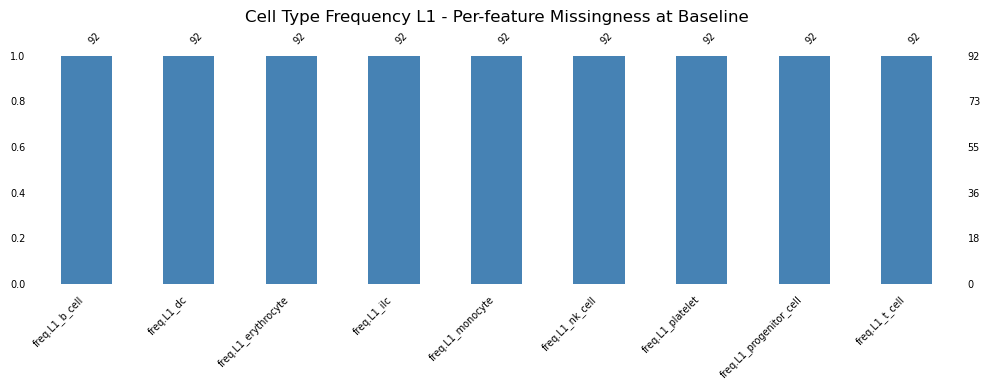

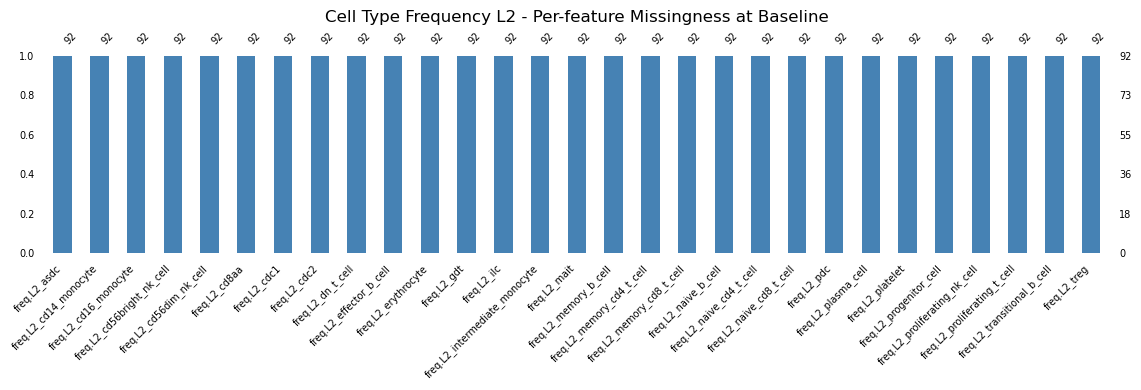

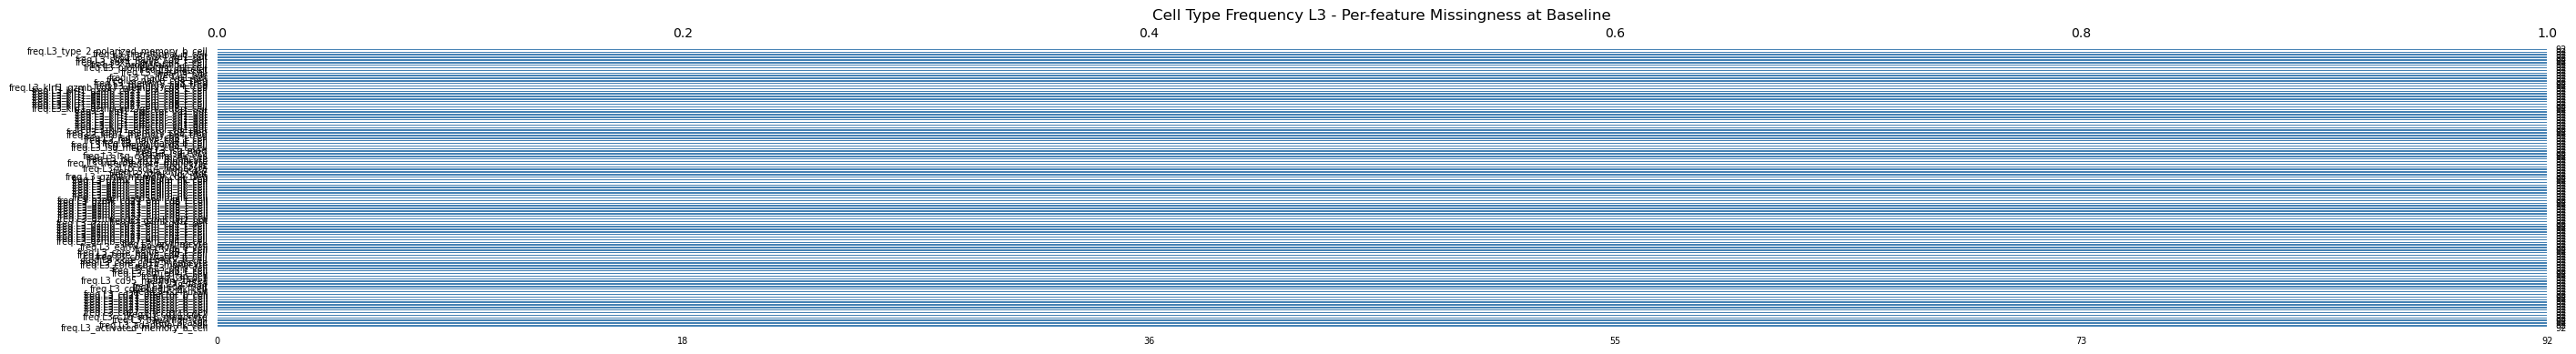

In [5]:
miss_summary = flag_missingness(wide_all[feat_cols])
n_candidates = miss_summary["exclude_candidate"].sum()
print("Features with >20% missing (exclude_candidate): " + str(n_candidates))
if n_candidates > 0:
    print(miss_summary[miss_summary["exclude_candidate"]].to_string())

for level, _ in LEVELS:
    level_cols = [c for c in feat_cols if c.startswith("freq." + level + "_")]
    fig, ax = plt.subplots(figsize=(max(10, len(level_cols) * 0.4), 4))
    msno.bar(wide_all[level_cols], ax=ax, fontsize=7, color="steelblue")
    ax.set_title("Cell Type Frequency " + level + " - Per-feature Missingness at Baseline")
    plt.tight_layout()
    plt.savefig(FIGURES / ("celltype_freq_" + level + "_missingness.png"), dpi=150)
    plt.show()

## Stage 5 - Feature Selection

All 109 features (L1x9 + L2x29 + L3x71) are retained so subsetting can happen at BN-fitting time. The team node budget targets ~29 cell-type nodes; the recommended subset is **L2 only**.

**NOTE - Potential exclusions across all levels (discuss before BN fitting):**

| Level | Column | Reason to Exclude |
|-------|--------|-------------------|
| L1 | `freq.L1_erythrocyte` | Red blood cells; PBMC prep contaminant; no immune-aging signal |
| L1 | `freq.L1_platelet` | Thrombocytes; not a lymphoid/myeloid immune cell |
| L1 | `freq.L1_progenitor_cell` | Undifferentiated precursor; not informative for steady-state immune aging |
| L2 | `freq.L2_erythrocyte` | Same as L1 |
| L2 | `freq.L2_platelet` | Same as L1 |
| L2 | `freq.L2_progenitor_cell` | Same as L1 |
| L3 | `freq.L3_erythrocyte` | Same as L1 |
| L3 | `freq.L3_platelet` | Same as L1 |
| L3 | `freq.L3_baeomap_cell` | Basophil/eosinophil/mast/platelet progenitor; bone-marrow lineage |
| L3 | `freq.L3_clp_cell` | Common lymphoid progenitor; bone-marrow lineage |
| L3 | `freq.L3_cmp_cell` | Common myeloid progenitor; bone-marrow lineage |

To exclude, drop these columns from the output or from `bn_ready_baseline.csv` at join time.

In [6]:
EXCLUDED_CANDIDATES = [
    # L1
    "freq.L1_erythrocyte", "freq.L1_platelet", "freq.L1_progenitor_cell",
    # L2
    "freq.L2_erythrocyte", "freq.L2_platelet", "freq.L2_progenitor_cell",
    # L3 - non-immune and bone-marrow progenitor types
    "freq.L3_erythrocyte", "freq.L3_platelet",
    "freq.L3_baeomap_cell", "freq.L3_clp_cell", "freq.L3_cmp_cell",
]

missing_flags = [c for c in EXCLUDED_CANDIDATES if c not in feat_cols]
if missing_flags:
    print("WARNING: flagged columns not found in output: " + str(missing_flags))

print("Total features retained:         " + str(len(feat_cols)))
print("Flagged for potential exclusion: " + str(len(EXCLUDED_CANDIDATES)))
print("After hypothetical exclusion:    " + str(len(feat_cols) - len(EXCLUDED_CANDIDATES)))

Total features retained:         109
Flagged for potential exclusion: 11
After hypothetical exclusion:    98


## Stage 6 - Export

In [7]:
enforce_export_contract(wide_all, prefix="freq.")
output_path = write_processed(wide_all, modality_name="celltype_freq", output_dir=str(PROCESSED))
print("Written: " + output_path)

level_rationale = {
    "L1": "Coarse resolution (9 types); retained for optional high-level comparisons.",
    "L2": "Intermediate resolution (29 types); recommended subset for BN fitting.",
    "L3": "Fine resolution (71 types); retained for exploratory use; too many for n~100 BN.",
}

manifest_entries = []
for col in feat_cols:
    level = col.split(".")[1].split("_")[0]  # extract L1/L2/L3 from freq.Lx_...
    exclusion_note = (
        "FLAGGED FOR POTENTIAL EXCLUSION: non-immune / progenitor type; discuss before BN fitting."
        if col in EXCLUDED_CANDIDATES else "Included."
    )
    manifest_entries.append({
        "feature_name": col,
        "modality": "cell_type_freq",
        "source_column": "AIFI_" + level + "_clr_pseudo",
        "rationale": (
            "AIFI " + level + " cell type frequency (CLR with pseudocount). "
            + level_rationale[level] + " " + exclusion_note
        ),
    })

append_manifest(manifest_entries, str(PROCESSED / "feature_manifest.csv"))
print("Manifest entries written: " + str(len(manifest_entries)))
print("\nManifest preview:")
pd.read_csv(PROCESSED / "feature_manifest.csv").head()

Written: ..\data\processed\celltype_freq_baseline_wide.csv
Manifest entries written: 109

Manifest preview:


,feature_name,modality,source_column,rationale
0,pb.activated_memory_b_cell_ifn_alpha,pseudobulk,"means layer (Seurat-normalized, log1p)",Pseudobulk L3 cell type 'activated_memory_b_ce...
1,pb.activated_memory_b_cell_ifn_gamma,pseudobulk,"means layer (Seurat-normalized, log1p)",Pseudobulk L3 cell type 'activated_memory_b_ce...
2,pb.activated_memory_b_cell_il2_stat5,pseudobulk,"means layer (Seurat-normalized, log1p)",Pseudobulk L3 cell type 'activated_memory_b_ce...
3,pb.activated_memory_b_cell_inflammatory,pseudobulk,"means layer (Seurat-normalized, log1p)",Pseudobulk L3 cell type 'activated_memory_b_ce...
4,pb.activated_memory_b_cell_tnfa_nfkb,pseudobulk,"means layer (Seurat-normalized, log1p)",Pseudobulk L3 cell type 'activated_memory_b_ce...
